In [25]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

***NVIDIA CASE***

In [26]:
tickers = "NVDA"
nvda = yf.Ticker(tickers)
data = nvda.history(start="2020-06-05", end="2021-06-05", interval="1d")
print(data.head())

                               Open      High       Low     Close     Volume  \
Date                                                                           
2020-06-05 00:00:00-04:00  8.764154  8.965954  8.677952  8.889220  481748000   
2020-06-08 00:00:00-04:00  8.846614  8.859071  8.655776  8.774614  387736000   
2020-06-09 00:00:00-04:00  8.769632  9.078313  8.721051  9.014783  468488000   
2020-06-10 00:00:00-04:00  9.136112  9.467215  9.121911  9.334425  632180000   
2020-06-11 00:00:00-04:00  9.118424  9.229290  8.755681  8.765896  583652000   

                           Dividends  Stock Splits  
Date                                                
2020-06-05 00:00:00-04:00        0.0           0.0  
2020-06-08 00:00:00-04:00        0.0           0.0  
2020-06-09 00:00:00-04:00        0.0           0.0  
2020-06-10 00:00:00-04:00        0.0           0.0  
2020-06-11 00:00:00-04:00        0.0           0.0  


In [27]:
close_prices = data['Close']
df_close = pd.DataFrame({"Date": close_prices.index, "Close": close_prices.values})
df_close.reset_index(drop=True, inplace=True)
print(df_close.head())

                       Date     Close
0 2020-06-05 00:00:00-04:00  8.889220
1 2020-06-08 00:00:00-04:00  8.774614
2 2020-06-09 00:00:00-04:00  9.014783
3 2020-06-10 00:00:00-04:00  9.334425
4 2020-06-11 00:00:00-04:00  8.765896


In [28]:
df_close.to_csv("/tmp/nvda_close_prices.csv", index=False)


In [29]:
df_nvidia = pd.read_csv("/tmp/nvda_close_prices.csv")
df_nvidia.head()

,Date,Close
0,2020-06-05 00:00:00-04:00,8.889220
1,2020-06-08 00:00:00-04:00,8.774614
2,2020-06-09 00:00:00-04:00,9.014783
3,2020-06-10 00:00:00-04:00,9.334425
4,2020-06-11 00:00:00-04:00,8.765896


/var/folders/62/rh9l84sx6d70_dkrpcr4kfbr0000gn/T/ipykernel_41130/1073677266.py:1: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df_nvidia['Date'] = pd.to_datetime(df_nvidia['Date'])


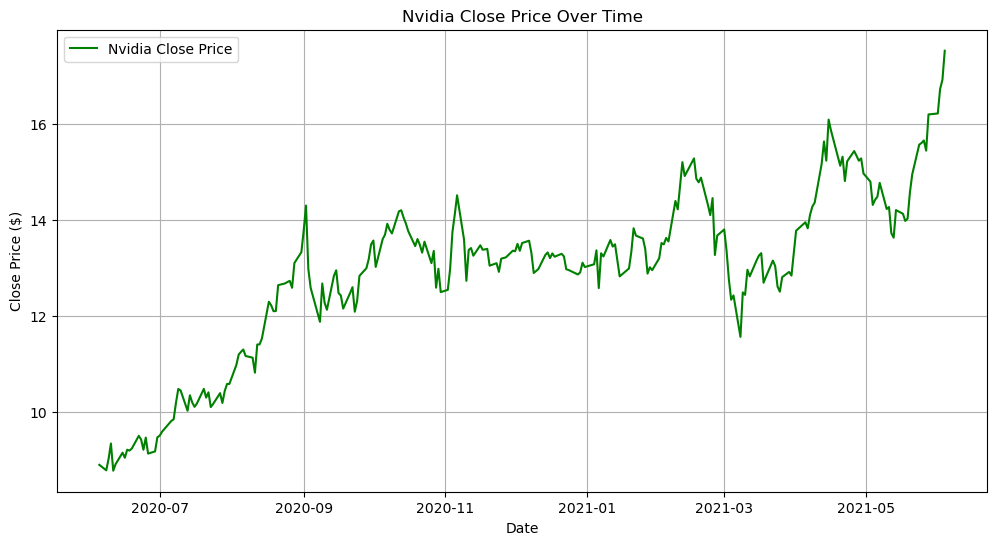

In [30]:
df_nvidia['Date'] = pd.to_datetime(df_nvidia['Date'])
df_nvidia.set_index('Date', inplace=True)
plt.figure(figsize=(12, 6))
plt.plot(df_nvidia.index, df_nvidia['Close'], color ='green', label='Nvidia Close Price')
plt.title('Nvidia Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price ($)')
plt.grid(True)
plt.legend()
plt.show()

***DATA COMPLETETENESS***

In [31]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 252 entries, 2020-06-05 00:00:00-04:00 to 2021-06-04 00:00:00-04:00
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          252 non-null    float64
 1   High          252 non-null    float64
 2   Low           252 non-null    float64
 3   Close         252 non-null    float64
 4   Volume        252 non-null    int64  
 5   Dividends     252 non-null    float64
 6   Stock Splits  252 non-null    float64
dtypes: float64(6), int64(1)
memory usage: 15.8 KB


In [32]:
data.describe()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,252.000000,252.000000,252.000000,252.000000,2.520000e+02,252.000000,252.0
mean,12.914225,13.118759,12.683205,12.911565,3.929790e+08,0.000048,0.0
std,1.734285,1.759794,1.717968,1.743985,1.881868e+08,0.000435,0.0
min,8.764154,8.859071,8.655776,8.765896,9.788400e+07,0.000000,0.0
25%,12.438207,12.611488,12.043697,12.425464,2.657420e+08,0.000000,0.0
50%,13.187448,13.387377,12.976709,13.201907,3.432580e+08,0.000000,0.0
75%,13.856102,14.052695,13.635135,13.808301,4.915600e+08,0.000000,0.0
max,17.069479,17.616600,17.052523,17.534060,1.463684e+09,0.004000,0.0


In [33]:
data.shape

(252, 7)

In [34]:
data.columns

Index(['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits'], dtype='object')

In [35]:
print(f"The missing values in the dataset: {data['Close'].isnull().sum()}")

The missing values in the dataset: 0


In [36]:
total_rows = len(data)

missing_info = pd.DataFrame({
    'missing_count': data.isnull().sum(),
    'missing_percentage': (data.isnull().sum() / total_rows) * 100
})

print(missing_info)


              missing_count  missing_percentage
Open                      0                 0.0
High                      0                 0.0
Low                       0                 0.0
Close                     0                 0.0
Volume                    0                 0.0
Dividends                 0                 0.0
Stock Splits              0                 0.0


***DATA LATENCY***

In [37]:
min_close = data['Close'].min()
max_close = data['Close'].max()
print(f"Minimum Close Price: {min_close}")
print(f"Maximum Close Price: {max_close}")
print(f"Difference between Max and Min Close Price: {max_close - min_close}")

Minimum Close Price: 8.76589584350586
Maximum Close Price: 17.534059524536133
Difference between Max and Min Close Price: 8.768163681030273


***DATA CONSISTENCY***

In [38]:
print(data.dtypes)

Open            float64
High            float64
Low             float64
Close           float64
Volume            int64
Dividends       float64
Stock Splits    float64
dtype: object


In [39]:
print(data.apply(lambda x: x.map(type).nunique()))

Open            1
High            1
Low             1
Close           1
Volume          1
Dividends       1
Stock Splits    1
dtype: int64


***ERROR RATE***

In [40]:
missing_rate = data.isnull().mean() * 100
print(missing_rate)

Open            0.0
High            0.0
Low             0.0
Close           0.0
Volume          0.0
Dividends       0.0
Stock Splits    0.0
dtype: float64


In [41]:
duplicate_rate = data.duplicated().mean() * 100
print(duplicate_rate)

0.0


In [42]:
Q1 = data['Close'].quantile(0.25)
Q3 = data['Close'].quantile(0.75)
IQR = Q3 - Q1
outliers = ((data['Close'] < Q1 - 1.5 * IQR) | (data['Close'] > Q3 + 1.5 * IQR)).mean() * 100
print(outliers)

15.079365079365079


***DATA ACCURACY***

In [43]:
minimum_price = data['Close'].min()
max_price = data['Close'].max()

print("The minimum recorded price is", minimum_price)

print("The maximum recorded price is", max_price)

The minimum recorded price is 8.76589584350586
The maximum recorded price is 17.534059524536133


In [44]:
negative_price_count = (data['Close'] < 0).sum()
print("Number of records with negative Close price:", negative_price_count)

Number of records with negative Close price: 0


In [45]:
valid_close = data['Close'] > 0
valid_volume = data['Volume'] > 0
valid_dividends = data['Dividends'].notnull()

accurate_records = data[valid_close & valid_volume & valid_dividends]
data_accuracy_rate = (len(accurate_records) / len(data)) * 100
print(f"✅ Data Accuracy Rate: {data_accuracy_rate:.2f}%")

✅ Data Accuracy Rate: 100.00%


In [46]:
invalid_records = data[~(valid_close & valid_volume & valid_dividends)]
invalid_value_rate = (len(invalid_records) / len(data)) * 100
print(f"❌ Invalid Value Rate: {invalid_value_rate:.2f}%")


❌ Invalid Value Rate: 0.00%


In [47]:
duplicate_rows = data.duplicated()
duplicate_accuracy_rate = ((~duplicate_rows).sum() / len(data)) * 100
print(f"📄 Duplicate Accuracy Rate: {duplicate_accuracy_rate:.2f}%")

📄 Duplicate Accuracy Rate: 100.00%


In [48]:
unit_price_accuracy = (data['Close'] > 0).sum() / len(data) * 100
print(f"💰 Close Price Field Accuracy Rate: {unit_price_accuracy:.2f}%")

💰 Close Price Field Accuracy Rate: 100.00%
